<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1789 | Val: 434 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[EfficientNet-B0] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2010 acc 0.492 | val loss 0.8318 acc 0.661 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.00e-04 | train loss 0.7754 acc 0.655 | val loss 0.6560 acc 0.726 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.00e-04 | train loss 0.6180 acc 0.718 | val loss 0.5244 acc 0.790 *


[EfficientNet-B0] Epoch   4/100 | LR: 1.00e-04 | train loss 0.5089 acc 0.761 | val loss 0.4598 acc 0.818 *


...

[EfficientNet-B0] Epoch  17/100 | LR: 1.00e-05 | train loss 0.1624 acc 0.931 | val loss 0.4375 acc 0.857


[EfficientNet-B0] Epoch  18/100 | LR: 1.00e-05 | train loss 0.1706 acc 0.928 | val loss 0.4409 acc 0.862


[EfficientNet-B0] Epoch  19/100 | LR: 1.00e-05 | train loss 0.1454 acc 0.939 | val loss 0.4443 acc 0.873


[EfficientNet-B0] Epoch  20/100 | LR: 1.00e-05 | train loss 0.1309 acc 0.934 | val loss 0.4582 acc 0.857


[EfficientNet-B0] Epoch  21/100 | LR: 1.00e-05 | train loss 0.1463 acc 0.933 | val loss 0.4339 acc 0.866

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 21.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.4110)


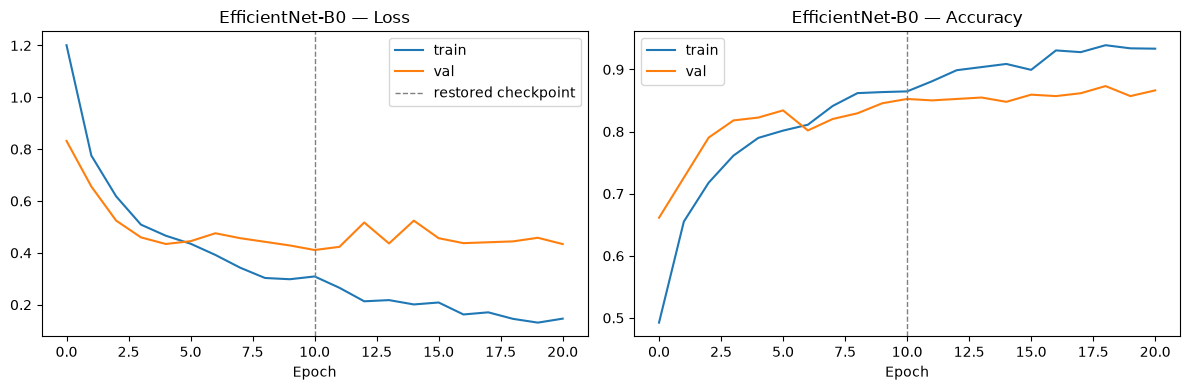

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.845


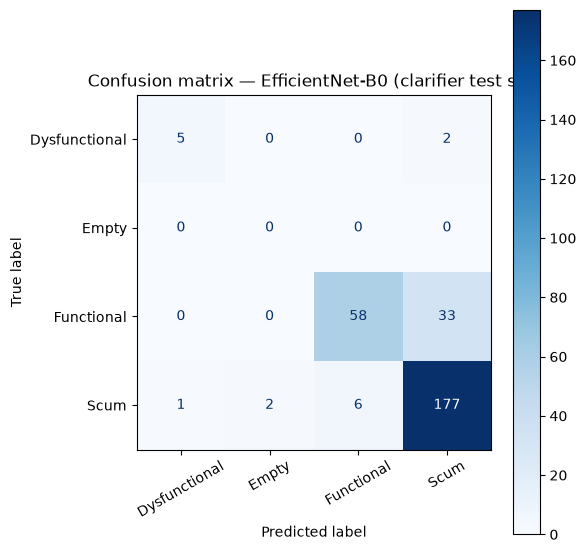

               precision    recall  f1-score   support

Dysfunctional      0.833     0.714     0.769         7
        Empty      0.000     0.000     0.000         0
   Functional      0.906     0.637     0.748        91
         Scum      0.835     0.952     0.889       186

     accuracy                          0.845       284
    macro avg      0.644     0.576     0.602       284
 weighted avg      0.858     0.845     0.841       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


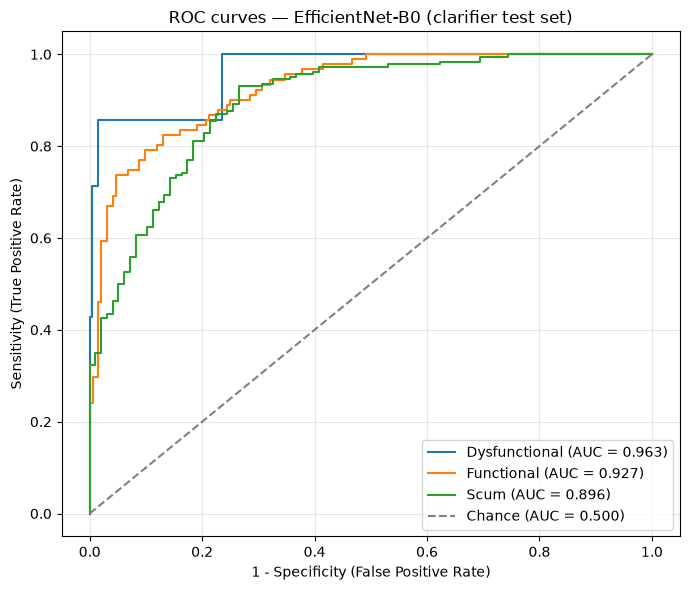

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.963
  Empty          : undefined (0 examples)
  Functional     : 0.927
  Scum           : 0.896

Mean AUC (over 3/4 classes with test examples): 0.929


(np.float64(0.8450704225352113),
 {'Dysfunctional': 0.963383187209902,
  'Empty': nan,
  'Functional': 0.9273472641348288,
  'Scum': 0.8959842001316656})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/results_clarifier_efficientnet_b0_Waterval.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
